In [95]:
#importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from feature_engineering import FeatureEngineer

import joblib


# Task 1

In [2]:
#reading HousePrice_POC and storing it in dataframe df
df = pd.read_csv("HousePrice_POC.csv")

In [3]:
#checking dataframe
df.head()

,house_id,area_sqft,bedrooms,bathrooms,floors,year_built,garage,locality,distance_to_city_km,school_rating,renovated,condition,price_inr
0,HSE76292,1887,4,3,1,1976,0,Urban,9.5,7.4,0,Average,139.13
1,HSE98254,2078,3,2,1,1981,1,Urban,7.7,9.4,0,Average,147.36
2,HSE45178,1614,4,4,1,1985,1,Urban,8.7,7.3,0,Good,160.27
3,HSE78189,2339,2,1,1,2007,0,Suburban,13.7,6.8,0,Excellent,142.87
4,HSE11370,2213,4,3,2,2016,1,Urban,7.5,3.2,0,Excellent,177.88


In [4]:
#checking shape of the df
df.shape

(1508, 13)

In [5]:
#checking datatypes
df.dtypes

house_id                object
area_sqft                int64
bedrooms                 int64
bathrooms                int64
floors                   int64
year_built               int64
garage                   int64
locality                object
distance_to_city_km    float64
school_rating          float64
renovated                int64
condition               object
price_inr              float64
dtype: object

In [6]:
#checking descriptive statistics of the data
df.describe()

,area_sqft,bedrooms,bathrooms,floors,year_built,garage,distance_to_city_km,school_rating,renovated,price_inr
count,1508.000000,1508.000000,1508.000000,1508.000000,1508.000000,1508.000000,1478.000000,1463.000000,1508.000000,1508.000000
mean,1791.230769,3.074271,2.701592,1.551061,1995.883952,0.671088,21.128958,6.473958,0.399204,137.482402
std,584.090886,0.949166,1.034801,0.675217,15.241578,0.469974,19.306090,2.054776,0.489897,48.901338
min,400.000000,1.000000,1.000000,1.000000,1970.000000,0.000000,1.000000,3.000000,0.000000,37.750000
25%,1394.750000,2.000000,2.000000,1.000000,1983.000000,0.000000,7.025000,4.700000,0.000000,114.702500
50%,1792.000000,3.000000,3.000000,1.000000,1996.000000,1.000000,14.750000,6.500000,0.000000,135.120000
75%,2202.750000,4.000000,3.000000,2.000000,2009.000000,1.000000,27.300000,8.300000,1.000000,154.670000
max,3604.000000,5.000000,5.000000,3.000000,2022.000000,1.000000,79.800000,10.000000,1.000000,677.121328


### Imputing Missing Values

In [7]:
#checking empty values
df.isna().sum()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
floors                  0
year_built              0
garage                  0
locality                0
distance_to_city_km    30
school_rating          45
renovated               0
condition               0
price_inr               0
dtype: int64

In [8]:
# checking percentage of empty values
null_percentage = round(df.isnull().mean() * 100,2)
null_percentage

house_id               0.00
area_sqft              0.00
bedrooms               0.00
bathrooms              0.00
floors                 0.00
year_built             0.00
garage                 0.00
locality               0.00
distance_to_city_km    1.99
school_rating          2.98
renovated              0.00
condition              0.00
price_inr              0.00
dtype: float64

**distance_to_city_km and school_ratings countains around 2% to 3%  null values we will fill the empty values using imputation methods**

In [9]:
df['distance_to_city_km'].value_counts()

distance_to_city_km
9.5     14
7.3     12
9.4     12
8.9     11
1.7     11
        ..
64.3     1
62.0     1
45.5     1
63.1     1
34.3     1
Name: count, Length: 503, dtype: int64

distance_to_city_km has range from 1km  79.8 km, we will be imputing it with median and not mean. As mean is sensitive to outliers, we will imputing the distance_to_city_km null value with median

In [10]:
# imputing distance_to_city_km null value with median
df['distance_to_city_km'] = df['distance_to_city_km'].fillna(df['distance_to_city_km'].median())
df['distance_to_city_km'].isna().sum()

np.int64(0)

In [11]:
#school_rating
df['school_rating'].value_counts()

school_rating
3.6     32
3.2     31
9.2     29
3.4     28
3.3     28
        ..
3.0     13
5.2     13
10.0    13
3.7     12
8.0     12
Name: count, Length: 71, dtype: int64

Filling School_Rating with 0 as there can be no school, thats why rating is missing

In [12]:
# imputing distance_to_city_km null value with 0 
df['school_rating'] = df['school_rating'].fillna(0)
df['school_rating'].isna().sum()

np.int64(0)

In [13]:
df.isna().sum()

house_id               0
area_sqft              0
bedrooms               0
bathrooms              0
floors                 0
year_built             0
garage                 0
locality               0
distance_to_city_km    0
school_rating          0
renovated              0
condition              0
price_inr              0
dtype: int64

**Dropping Duplicat values**

In [14]:
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

Shape after dropping duplicates: (1500, 13)


There were 8 duplicates records in the dataframe

**Converting object datatype to Category datatype.**

In [15]:
cat_cols = ['locality', 'condition']
df[cat_cols] = df[cat_cols].astype('category')

In [16]:
df.dtypes

house_id                 object
area_sqft                 int64
bedrooms                  int64
bathrooms                 int64
floors                    int64
year_built                int64
garage                    int64
locality               category
distance_to_city_km     float64
school_rating           float64
renovated                 int64
condition              category
price_inr               float64
dtype: object

# Task 2 - EDA

### Price Distribution

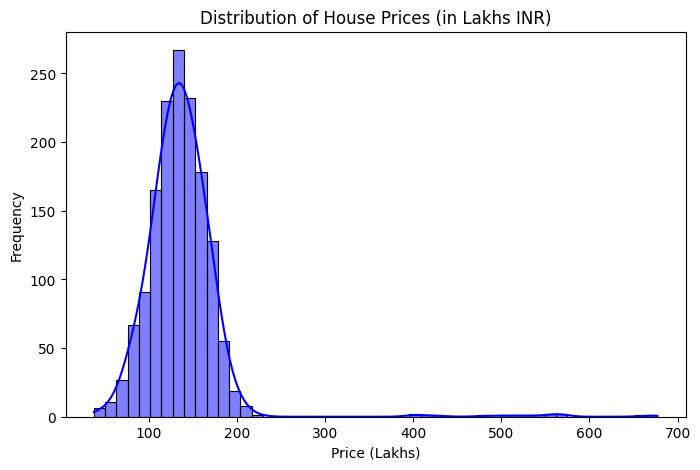

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price_inr'], bins=50, kde=True, color='blue')
plt.title('Distribution of House Prices (in Lakhs INR)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

The price distribution is approximately normal but slightly right-skewed. Most houses are concentrated in the range of 100 to 180 lakhs. There is a long tail on the higher end, indicating a few very expensive properties. Market is dominated by mid range properties with small number of luxury homes

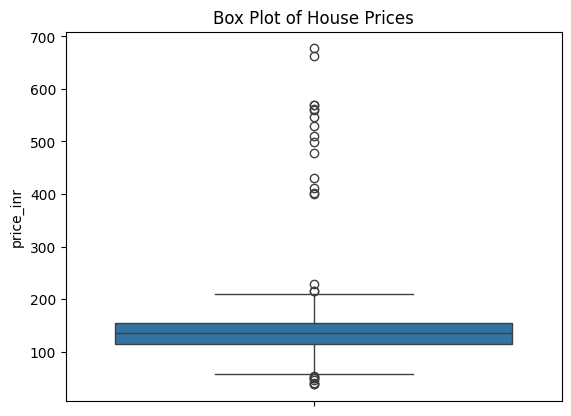

In [18]:
sns.boxplot(df['price_inr'])
plt.title("Box Plot of House Prices")
plt.show()
          


The box plot clearly shows multiple high-value outliers (210–700 lakhs range). There are also a few low-end outliers, but they are less extreme. The median lies slightly below the centre, indicating right skewness. These high-value outliers tell that they are luxury homes or prime location properties

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['area_sqft',
 'bedrooms',
 'bathrooms',
 'floors',
 'year_built',
 'garage',
 'distance_to_city_km',
 'school_rating',
 'renovated',
 'price_inr']

### Numerical Correlation

In [20]:
correlation = df[num_cols].corr()
correlation

,area_sqft,bedrooms,bathrooms,floors,year_built,garage,distance_to_city_km,school_rating,renovated,price_inr
area_sqft,1.000000,0.008556,0.012369,-0.008029,-0.001734,0.007189,-0.016694,-0.006767,-0.018033,0.387614
bedrooms,0.008556,1.000000,0.884438,-0.014958,0.020889,-0.008538,0.027739,-0.000183,0.059993,0.092733
bathrooms,0.012369,0.884438,1.000000,-0.008938,0.009577,-0.006656,0.010045,-0.018326,0.085619,0.080563
floors,-0.008029,-0.014958,-0.008938,1.000000,0.022120,-0.026772,0.010233,0.013618,-0.004430,-0.006079
year_built,-0.001734,0.020889,0.009577,0.022120,1.000000,0.017461,-0.027058,-0.005658,0.027150,0.065875
garage,0.007189,-0.008538,-0.006656,-0.026772,0.017461,1.000000,-0.022162,-0.021734,-0.002894,0.038845
distance_to_city_km,-0.016694,0.027739,0.010045,0.010233,-0.027058,-0.022162,1.000000,-0.022244,0.003169,-0.332176
school_rating,-0.006767,-0.000183,-0.018326,0.013618,-0.005658,-0.021734,-0.022244,1.000000,0.008489,0.103882
renovated,-0.018033,0.059993,0.085619,-0.004430,0.027150,-0.002894,0.003169,0.008489,1.000000,0.060475
price_inr,0.387614,0.092733,0.080563,-0.006079,0.065875,0.038845,-0.332176,0.103882,0.060475,1.000000


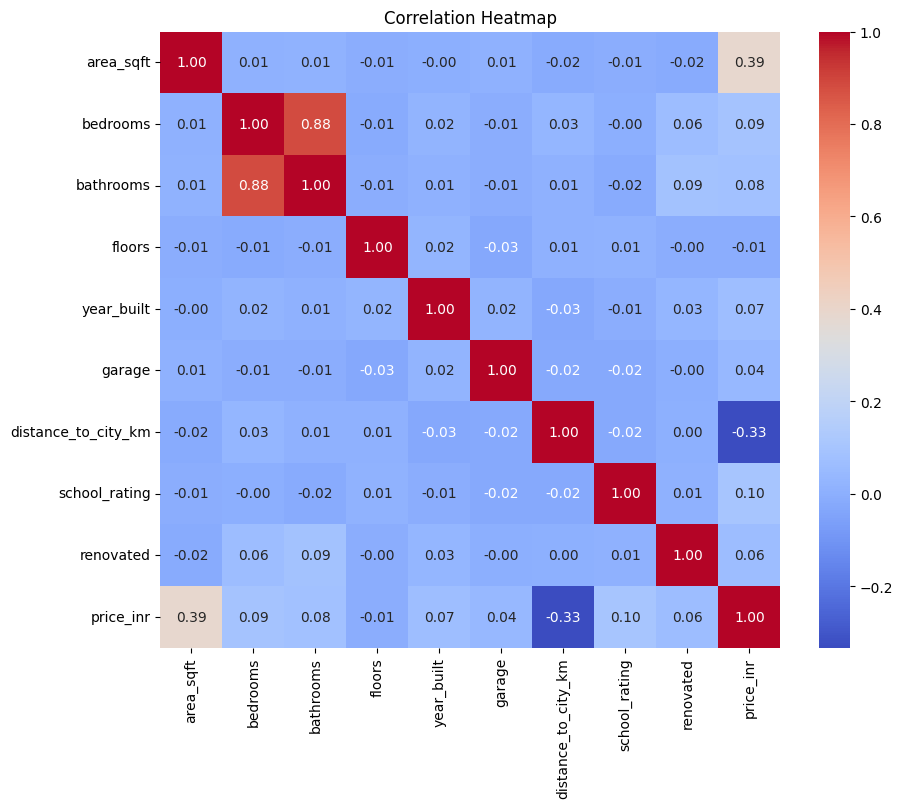

In [21]:
# plotting heatmap usill all methods for all numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

1) Bedrooms and Bathrooms are highly correlated and can cause multicollinearity as naturally large homes will have more bedrooms and bathrooms.
2) **Area_Sqft** is a strong predictor and influence on the target variable price.
3) **distance_to_city_km** has a moderately negative correlation with price. As distance increases, prices decrease. Houses closer to the city are costlier compared to houses which are away from the city.
4) Floors, Garage and renovation show almost zero correlation.

In [22]:
cat_cols = df.select_dtypes(include=['category']).columns.tolist()
cat_cols

['locality', 'condition']

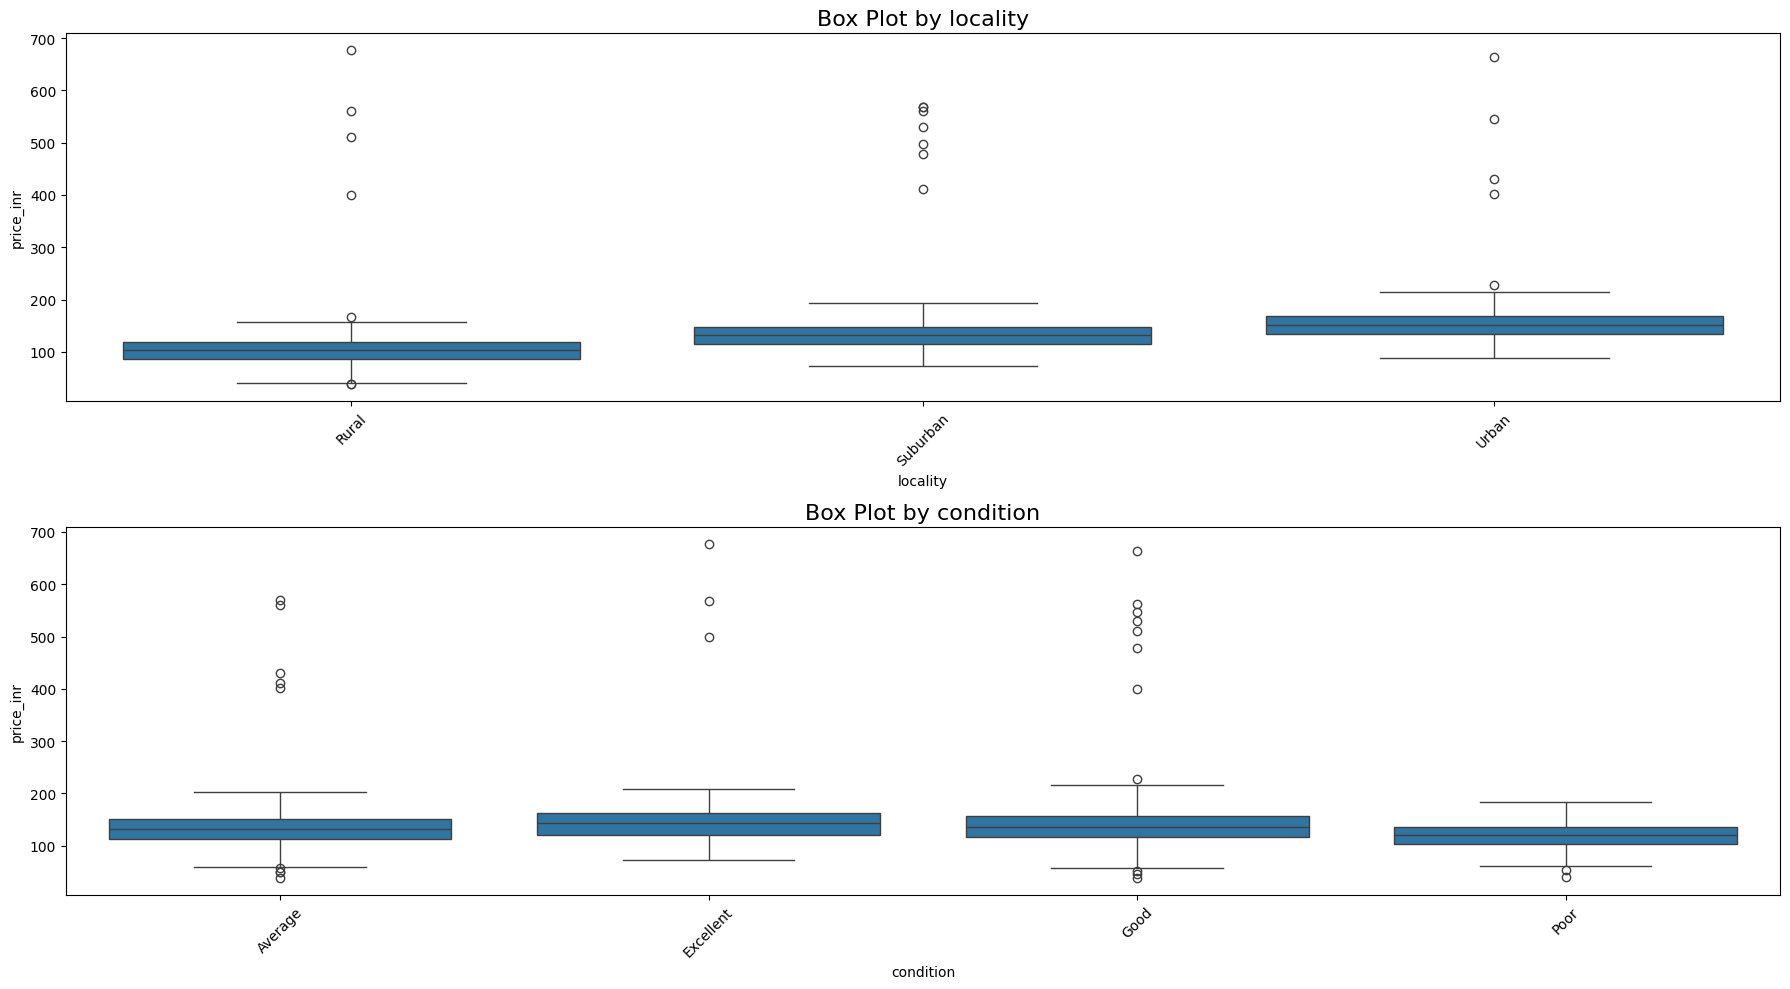

In [151]:
plt.figure(figsize=(18,10))
for i,j in enumerate(cat_cols):

    plt.subplot(2,1,i+1)
    
    sns.boxplot(x=j,y='price_inr',data=df)
    plt.title(f'Box Plot by {j}', fontsize=16)
    
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

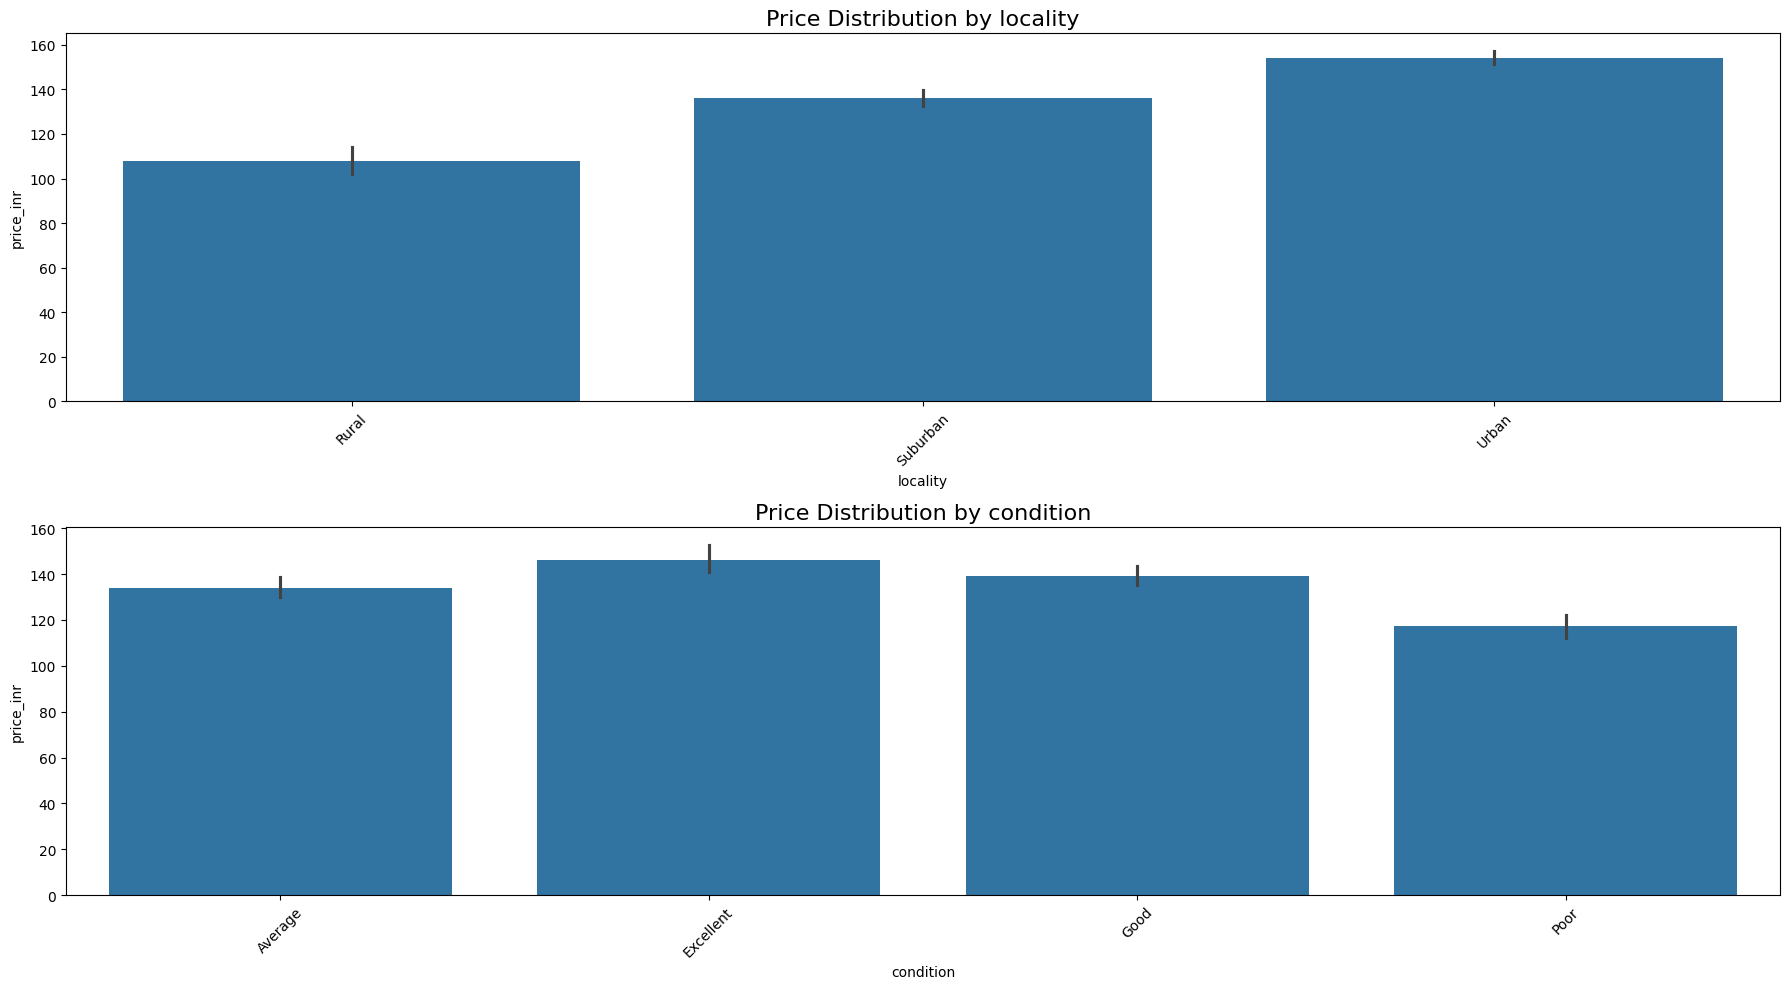

In [152]:
plt.figure(figsize=(18,10))
for i,j in enumerate(cat_cols):

    plt.subplot(2,1,i+1)
    
    sns.barplot(x=j,y='price_inr',data=df)
    plt.title(f'Price Distribution by {j}', fontsize=16)
    
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1) Locality - Urban area has more expensive house, followed by suburban and rural
2) Condition significantly shifts price distribution. Excellent condition house has higher price followed by Good, Average and Poor.

# Task 3 - Feature Engineering and Preprocessing

### Feature Engineering

In [25]:
df.columns

Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'floors',
       'year_built', 'garage', 'locality', 'distance_to_city_km',
       'school_rating', 'renovated', 'condition', 'price_inr'],
      dtype='object')

In [26]:
current_year = datetime.now().year
current_year

2026

In [148]:
#creating feature age of house
df['house_age'] = current_year - df['year_built']
df.head()

,house_id,area_sqft,bedrooms,bathrooms,floors,year_built,garage,locality,distance_to_city_km,school_rating,renovated,condition,price_inr,house_age,area_per_room,is_luxury
0,HSE76292,1887,4,3,1,1976,0,Urban,9.5,7.4,0,Average,139.13,50,269.571429,0
1,HSE98254,2078,3,2,1,1981,1,Urban,7.7,9.4,0,Average,147.36,45,415.600000,0
2,HSE45178,1614,4,4,1,1985,1,Urban,8.7,7.3,0,Good,160.27,41,201.750000,0
3,HSE78189,2339,2,1,1,2007,0,Suburban,13.7,6.8,0,Excellent,142.87,19,779.666667,0
4,HSE11370,2213,4,3,2,2016,1,Urban,7.5,3.2,0,Excellent,177.88,10,316.142857,1


In [149]:
# creating area_per_room feature
df['area_per_room'] = df['area_sqft'] / (df['bedrooms'] + df['bathrooms']) 
df.head(5)

,house_id,area_sqft,bedrooms,bathrooms,floors,year_built,garage,locality,distance_to_city_km,school_rating,renovated,condition,price_inr,house_age,area_per_room,is_luxury
0,HSE76292,1887,4,3,1,1976,0,Urban,9.5,7.4,0,Average,139.13,50,269.571429,0
1,HSE98254,2078,3,2,1,1981,1,Urban,7.7,9.4,0,Average,147.36,45,415.600000,0
2,HSE45178,1614,4,4,1,1985,1,Urban,8.7,7.3,0,Good,160.27,41,201.750000,0
3,HSE78189,2339,2,1,1,2007,0,Suburban,13.7,6.8,0,Excellent,142.87,19,779.666667,0
4,HSE11370,2213,4,3,2,2016,1,Urban,7.5,3.2,0,Excellent,177.88,10,316.142857,1


In [150]:
#creating feature is_luxury to identify if the house is luxury is or nor
df['is_luxury'] = ((df['area_sqft'] > df['area_sqft'].quantile(0.75)) & (df['bathrooms'] >= 3) & (df['garage'] == 1)).astype(int)
df.head(5)

,house_id,area_sqft,bedrooms,bathrooms,floors,year_built,garage,locality,distance_to_city_km,school_rating,renovated,condition,price_inr,house_age,area_per_room,is_luxury
0,HSE76292,1887,4,3,1,1976,0,Urban,9.5,7.4,0,Average,139.13,50,269.571429,0
1,HSE98254,2078,3,2,1,1981,1,Urban,7.7,9.4,0,Average,147.36,45,415.600000,0
2,HSE45178,1614,4,4,1,1985,1,Urban,8.7,7.3,0,Good,160.27,41,201.750000,0
3,HSE78189,2339,2,1,1,2007,0,Suburban,13.7,6.8,0,Excellent,142.87,19,779.666667,0
4,HSE11370,2213,4,3,2,2016,1,Urban,7.5,3.2,0,Excellent,177.88,10,316.142857,1


### Preprocessing

In [30]:
df.columns


Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'floors',
       'year_built', 'garage', 'locality', 'distance_to_city_km',
       'school_rating', 'renovated', 'condition', 'price_inr', 'house_age',
       'area_per_room', 'is_luxury'],
      dtype='object')

In [31]:
num_cols = [
    'area_sqft', 'bedrooms', 'bathrooms', 'floors',
    'year_built', 'garage', 'distance_to_city_km',
    'school_rating', 'renovated', 'house_age',
    'area_per_room', 'is_luxury'
]

cat_cols = ['locality', 'condition']

In [154]:
# Splitting the data into independent and dependent variables
X = df.drop(['price_inr', 'house_id'], axis=1)
Y = df['price_inr']

In [33]:
# Create bins for stratification
y_bins = pd.qcut(Y, q=5, labels=False)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=y_bins)

In [153]:
# creating pipeline for transforming and scaling the categorical and numerical column
preprocessor = ColumnTransformer([('num',StandardScaler(),num_cols),('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_cols)])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Task 4: Train & compare two models

### Linear Regression

In [113]:
#Linear Regression Pipeline
linear_regression_pipeline = Pipeline([('preprocessing',preprocessor),('model',LinearRegression())])
linear_regression_pipeline

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [114]:
#Training Model
linear_regression_pipeline.fit(X_train,Y_train)

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [115]:
#Predicting using Linear Regression model
y_pred_lr = linear_regression_pipeline.predict(X_test)

In [116]:
# Model Evaluation function
def evaluate(y_true, y_pred, model_name):
    '''
    Input - Y_train, Y_predicted and Model Name
    Output - R- Square, MAE, RMSE Score
    '''
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} Model Evalutation ")
    print("RMSE:", round(rmse,2))
    print("MAE :", round(mae,2))
    print("R²  :", round(r2,3))
    print("-"*30)

In [167]:
# Plotting Predicted vs Actual Values function
import matplotlib.pyplot as plt

def plot_predicted(model, X_test, y_test, model_name="Model"):
    """
    Plots Actual vs Predicted values for a regression model
    
    Parameters:
    - model: trained model (pipeline or estimator)
    - X_test: test features
    - y_test: actual values
    - model_name: name for title
    """
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.6,label="Predicted vs Actual")
    
    # Perfect prediction line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',label="Perfect Prediction"
    )
    
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Actual vs Predicted Prices ({model_name})")

    plt.legend()
    
    plt.show()



In [168]:
#evaluating the Linerar Regression Model
evaluate(Y_test,y_pred_lr,"LinearRegression")

LinearRegression Model Evalutation 
RMSE: 44.24
MAE : 12.26
R²  : 0.266
------------------------------


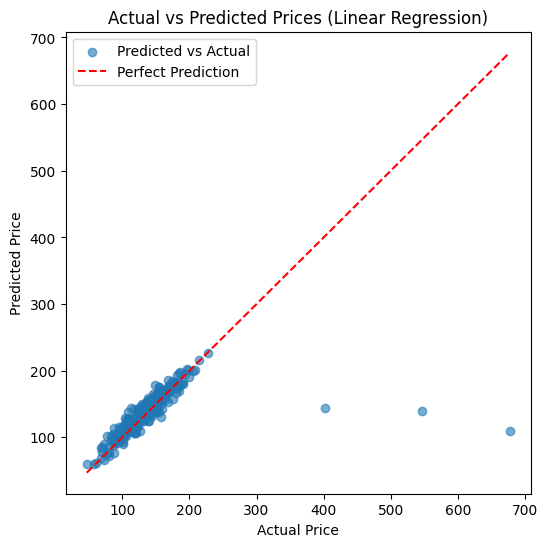

In [169]:
#plotting predicted value vs acutal value
plot_predicted(linear_regression_pipeline, X_test, Y_test, "Linear Regression")

The model shows strong generalization for common price ranges but struggles with high-value outliers, suggesting the need for either more balanced data or specialized modeling for luxury properties.

### Random Forest

In [124]:
#random forest pipeline
random_forest_pipeline = Pipeline([('preprocess',preprocessor),('model',RandomForestRegressor(random_state=12))])
random_forest_pipeline

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [175]:
# parameter grid to find the best parameters
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [176]:
# hypertunning Parameters using Grid Search CV
random_forest_grid_search = GridSearchCV(
    random_forest_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [177]:
#training the model
random_forest_grid_search.fit(X_train,Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [178]:
print("Best Parameters:", random_forest_grid_search.best_params_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}


In [179]:

best_model = random_forest_grid_search.best_estimator_

In [180]:
best_model

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [181]:
# predicting
y_pred_rf = best_model.predict(X_test)

In [182]:
#model evaluation
evaluate(Y_test,y_pred_rf,"RandomForestRegressor")

RandomForestRegressor Model Evalutation 
RMSE: 45.16
MAE : 14.9
R²  : 0.235
------------------------------


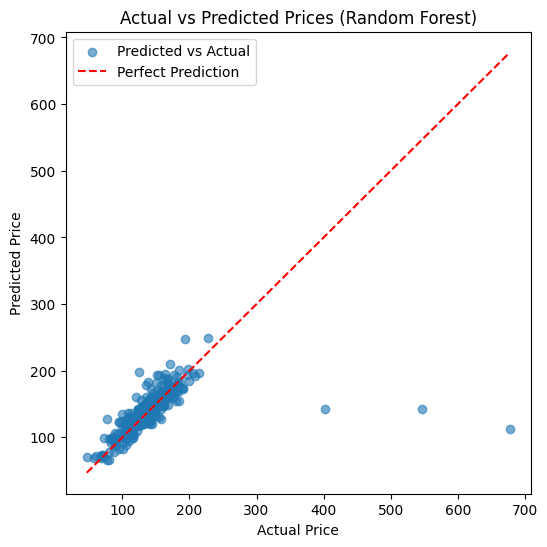

In [183]:
plot_predicted(best_model, X_test, Y_test, "Random Forest")

The model shows strong generalization for common price ranges but struggles with high-value outliers, suggesting the need for either more balanced data or specialized modeling for luxury properties.

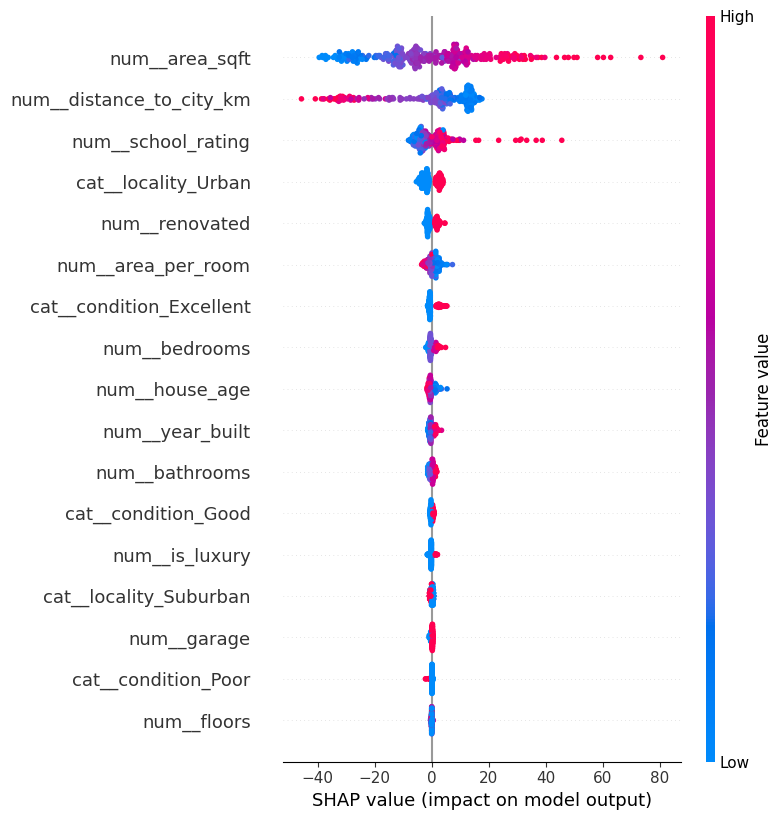

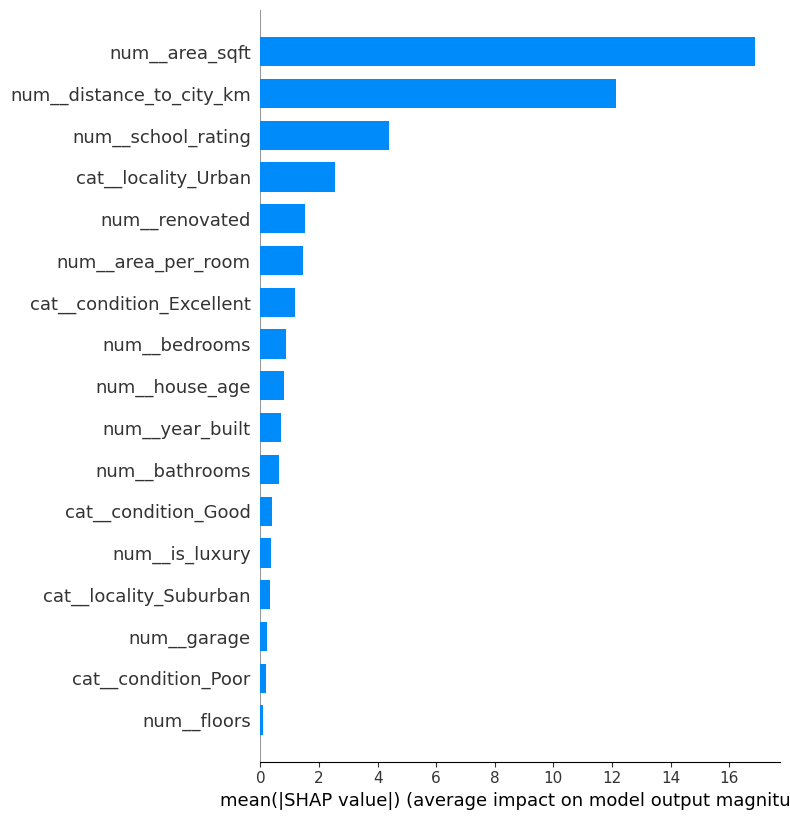

In [186]:
import shap

# Extract components
preprocess = best_model.named_steps['preprocessing']
rf_model = best_model.named_steps['model']


# 2. TRANSFORM TEST DATA
X_test_transformed = preprocess.transform(X_test)


# 3. GET CORRECT FEATURE NAMES
feature_names = preprocess.get_feature_names_out()
explainer = shap.TreeExplainer(rf_model)


# 4. CALCULATE SHAP VALUES
shap_values = explainer.shap_values(X_test_transformed)


# 6. SUMMARY PLOT 
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)


# 7. BAR PLOT 
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)


# Conclusion

Linear Regression Model Output: 
* RMSE: 44.24
* MAE : 12.26
* R²  : 0.266


Random Forest Model Output:
* RMSE: 45.08
* MAE : 14.68
* R²  : 0.238

The choice here is fairly straightforward: go with the Linear Regression model.

Here’s why:

Lower RMSE (44.24 vs 45.08) → better at handling larger errors
Lower MAE (12.26 vs 14.68) → more accurate on average predictions
Higher R² (0.266 vs 0.238) → explains more variance in the data

So across all three key metrics, Linear Regression is outperforming Random Forest.


Both models have low R² (~0.25), which means they’re only explaining about 25% of the variance. So while Linear Regression is the better of the two, neither model is particularly strong yet.

### Top Drivers of Price
1) **area_sqft**: Biggest impact on price: Larger houses → higher price
2) distance_to_city_km: Second most important. Location matters heavily
3) school_rating: Quality of nearby schools influences price
4) locality_Urban: Urban properties are more expensive
5) area_per_room: Space efficiency matters (luxury signal)

### SHAP Value Interpretation
1) Red (high area) → positive SHAP → increases price
Blue (small area) → decreases price. Indicating Strong linear relationship

2. distance_to_city_km
Red (far from city) → negative impact
Blue (closer) → increases price



### Scope of Improvement
* Increase the size of the dataset
* Hypertune the model parameter
* Perform feature Engineering
* Understand the data better by doing EDA
  



### Combining All into One and predicting the house price using Random Forest model

In [187]:
from sklearn.base import BaseEstimator, TransformerMixin
class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        # Store threshold from training data
        self.area_threshold_ = X['area_sqft'].quantile(0.75)
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # Feature engineering
        X['house_age'] = datetime.now().year - X['year_built']
        X['area_per_room'] = X['area_sqft'] / (X['bedrooms'] + X['bathrooms'])
        
        # Use stored threshold (IMPORTANT)
        X['is_luxury'] = (
            (X['area_sqft'] > self.area_threshold_) &
            (X['bathrooms'] >= 3) &
            (X['garage'] == 1)
        ).astype(int)
        
        return X

In [188]:
random_forest_pipeline = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, min_samples_split=10,min_samples_leaf=4,random_state=42))
])

In [189]:
random_forest_pipeline.fit(X_train,Y_train)

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [190]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [191]:
evaluate(Y_test,y_pred_rf,"RandomForestRegressor")

RandomForestRegressor Model Evalutation 
RMSE: 45.16
MAE : 14.9
R²  : 0.235
------------------------------


In [192]:
#predict function to predict house price
import pandas as pd

def predict_price(input_data, model):
    """
    input_data: dict (raw user input)
    model: trained pipeline
    """
    
    # Convert input to DataFrame
    df = pd.DataFrame([input_data])
    
    # Predict using pipeline (feature engineering happens inside)
    prediction = model.predict(df)[0]
    
    return round(prediction, 2)

In [196]:
sample_house = {
    'area_sqft': 1800,
    'bedrooms': 3,
    'bathrooms': 2,
    'floors': 2,
    'year_built': 2015,
    'garage': 1,
    'locality': 'Urban',
    'distance_to_city_km': 5,
    'school_rating': 8,
    'renovated': 0,
    'condition': 'Good'
}
#predicting price
predict_price(sample_house,random_forest_pipeline)

np.float64(155.46)

In [195]:
# saving model
joblib.dump(random_forest_pipeline, 'house_price_model_rf.pkl')

['house_price_model_rf.pkl']